In [19]:
import pandas as pd

df = pd.read_csv(r"C:\Users\panda\OneDrive\Desktop\KDDTrain+WithHeader-Labeled.csv")
print(df.head())
print(df['label'].value_counts())


   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [20]:
# Step 2: Preprocess and Encode Features
# Identify categorical features automatically (excluding the target column)
cat_cols = df.select_dtypes(include=['object']).columns.drop('label', errors='ignore')
df = pd.get_dummies(df, columns=cat_cols)

# Extract target
y = df['label'].map({'normal': 0, 'anomaly': 1})
X = df.drop(columns=['label'])

In [21]:
# Step 3: Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [23]:
# Step 4: Train an Anomaly Detection Model

In [24]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [25]:
# Step 5: Evaulate the Model

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20083
           1       1.00      1.00      1.00     17709

    accuracy                           1.00     37792
   macro avg       1.00      1.00      1.00     37792
weighted avg       1.00      1.00      1.00     37792



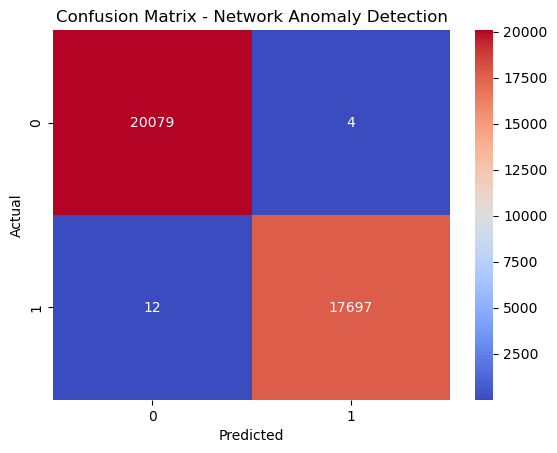

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Network Anomaly Detection')
plt.show()


In [27]:
# Step 6: Try it Yourself

In [28]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Feature reduction
pca = PCA(n_components=10)
X_reduced = pca.fit_transform(X)

# Train again with reduced features
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.3, random_state=42
)
clf.fit(X_train_r, y_train_r)


RandomForestClassifier(random_state=42)